In [3]:

!pip install monai nibabel xgboost openpyxl --quiet



from google.colab import drive
drive.mount('/content/drive')


import gc
import os
import random
import warnings
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import (
    StratifiedGroupKFold
)

from sklearn.preprocessing import (
    StandardScaler
)

from xgboost import XGBClassifier

from monai.networks.nets import resnet

from monai.transforms import (
    Compose,
    RandAffine
)

warnings.filterwarnings('ignore')



SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


MRI_PATH = Path('/content/drive/MyDrive/MLPR_Project/DeepBET_Output')

DEMOGRAPHICS_PATH = ('/content/drive/MyDrive/oasis_longitudinal_demographics-8d83e569fa2e2d30.xlsx')

SAVE_DIR = Path('/content/drive/MyDrive/OASIS_RESULTS')

SAVE_DIR.mkdir(exist_ok=True)

TARGET_SHAPE = (64, 64, 64)

BATCH_SIZE = 4

NUM_WORKERS = 0


EPOCHS = 20

EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 2e-4

N_SPLITS = 4

EMBEDDING_DIM = 64




device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print('Device:', device)

if torch.cuda.is_available():

    print(
        torch.cuda.get_device_name(0)
    )

    torch.backends.cudnn.benchmark = True


def map_cdr(cdr):

    if cdr == 0:
        return 0

    elif cdr == 0.5:
        return 1

    else:
        return 2


severity_names = {
    0: 'Non Demented',
    1: 'Very Mild',
    2: 'Demented'
}


df_demo = pd.read_excel(
    DEMOGRAPHICS_PATH
)

print('\nOriginal rows:', len(df_demo))


df_demo['Clean_ID'] = (

    df_demo['Subject ID']

    .astype(str)

    .apply(
        lambda x:
        x.split('_MR')[0]
    )
)




df_demo = df_demo.dropna(
    subset=['CDR']
)



# CDR -> Severity
df_demo['Severity'] = (

    df_demo['CDR']

    .apply(map_cdr)
)



df_demo['M/F'] = (

    df_demo['M/F']

    .map({
        'M': 0,
        'F': 1
    })
)


# Clinical Features


clinical_features = [

    'Age',

    'MMSE',

    'SES',

    'EDUC',

    'nWBV',

    'eTIV',

    'ASF',

    'M/F'
]



# Imputation

imputer = SimpleImputer(
    strategy='median'
)

df_demo[clinical_features] = (

    imputer.fit_transform(
        df_demo[clinical_features]
    )
)


clean_csv_path = (
    SAVE_DIR /
    'cleaned_demographics.csv'
)

df_demo.to_csv(
    clean_csv_path,
    index=False
)

print(
    '\nSaved cleaned demographics.'
)




print('\nSeverity Distribution:\n')

print(
    df_demo['Severity']
    .value_counts()
)


# Augmentation

train_transforms = Compose([

    RandAffine(

        prob=0.25,

        rotate_range=(
            0.05,
            0.05,
            0.05
        ),

        scale_range=(
            0.05,
            0.05,
            0.05
        ),

        padding_mode='border'
    )

])



def find_all_scans(root):

    scans = []

    unmatched_patients = []

    for patient_folder in sorted(
        root.iterdir()
    ):

        if not patient_folder.is_dir():
            continue

        patient_id = patient_folder.name

        subject_rows = df_demo[
            df_demo['Clean_ID']
            == patient_id
        ]

        if len(subject_rows) == 0:

            unmatched_patients.append(
                patient_id
            )

            continue

        subject_row = subject_rows.iloc[0]

        severity = int(
            subject_row['Severity']
        )

        clinical_vector = (

            subject_row[
                clinical_features
            ]

            .values

            .astype(np.float32)
        )

        for label_folder in sorted(
            patient_folder.iterdir()
        ):

            if not label_folder.is_dir():
                continue

            brain_folder = (
                label_folder / 'brain'
            )

            if not brain_folder.exists():
                continue

            scan_files = (

                list(
                    brain_folder.glob('*.nii')
                )

                +

                list(
                    brain_folder.glob(
                        '*.nii.gz'
                    )
                )
            )

            for scan_file in scan_files:

                scans.append({

                    'patient_id':
                    patient_id,

                    'filepath':
                    scan_file,

                    'severity':
                    severity,

                    'clinical':
                    clinical_vector
                })

    print(
        '\nUnmatched patients:',
        len(unmatched_patients)
    )

    return scans


all_scans = find_all_scans(
    MRI_PATH
)

print(
    '\nTotal scans:',
    len(all_scans)
)




def preprocess_volume(filepath):

    img = nib.load(
        str(filepath)
    )

    volume = img.get_fdata()

    volume = volume.astype(
        np.float32
    )

    while volume.ndim > 3:

        volume = volume.squeeze(-1)

    mean = volume.mean()

    std = volume.std()

    if std > 0:

        volume = (
            volume - mean
        ) / std

    volume = torch.tensor(volume)

    volume = (

        volume

        .unsqueeze(0)

        .unsqueeze(0)
    )

    volume = F.interpolate(

        volume,

        size=TARGET_SHAPE,

        mode='trilinear',

        align_corners=False
    )

    volume = volume.squeeze(0)

    return volume


class OASISDataset(Dataset):

    def __init__(
        self,
        scan_list,
        transforms=None
    ):

        self.scan_list = scan_list

        self.transforms = transforms

    def __len__(self):

        return len(
            self.scan_list
        )

    def __getitem__(self, idx):

        sample = self.scan_list[idx]

        volume = preprocess_volume(
            sample['filepath']
        )

        if self.transforms:

            volume = (
                self.transforms(volume)
                .float()
            )

        label = torch.tensor(
            sample['severity'],
            dtype=torch.long
        )

        clinical = torch.tensor(
            sample['clinical'],
            dtype=torch.float32
        )

        return (
            volume,
            label,
            clinical,
            sample['patient_id']
        )



class HybridResNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = (
            resnet.resnet18(
                spatial_dims=3,
                n_input_channels=1,
                num_classes=3
            )
        )


        for param in (
            self.backbone.parameters()
        ):
            param.requires_grad = False


        for param in (
            self.backbone
            .layer4
            .parameters()
        ):
            param.requires_grad = True

        feature_dim = (
            self.backbone
            .fc
            .in_features
        )

        self.backbone.fc = nn.Identity()

        self.embedding_head = nn.Sequential(

            nn.Linear(
                feature_dim,
                EMBEDDING_DIM
            ),

            nn.ReLU(),

            nn.Dropout(0.4)
        )

        self.classifier = nn.Linear(
            EMBEDDING_DIM,
            3
        )

    def forward(self, x):

        features = self.backbone(x)

        embeddings = (
            self.embedding_head(
                features
            )
        )

        logits = self.classifier(
            embeddings
        )

        return logits, embeddings




patient_to_label = {}

for scan in all_scans:

    patient_to_label[
        scan['patient_id']
    ] = scan['severity']

patients = np.array(
    list(patient_to_label.keys())
)

labels = np.array(
    list(patient_to_label.values())
)





sgkf = StratifiedGroupKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED
)

fold_accuracies = []



for fold, (

    train_idx,

    val_idx

) in enumerate(

    sgkf.split(

        patients,

        labels,

        groups=patients
    )

):

    print('\n' + '=' * 60)

    print(f'FOLD {fold+1}')

    print('=' * 60)

    train_patients = (
        patients[train_idx]
    )

    val_patients = (
        patients[val_idx]
    )

    train_scans = [

        s for s in all_scans

        if s['patient_id']
        in train_patients
    ]

    val_scans = [

        s for s in all_scans

        if s['patient_id']
        in val_patients
    ]

    print(
        'Train scans:',
        len(train_scans)
    )

    print(
        'Validation scans:',
        len(val_scans)
    )




    train_dataset = OASISDataset(
        train_scans,
        transforms=train_transforms
    )

    val_dataset = OASISDataset(
        val_scans
    )




    train_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=True,

        num_workers=NUM_WORKERS,

        pin_memory=True
    )

    val_loader = DataLoader(

        val_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=True
    )




    model = HybridResNet().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(

        filter(
            lambda p:
            p.requires_grad,

            model.parameters()
        ),

        lr=LEARNING_RATE
    )

    scaler = (
        torch.cuda.amp.GradScaler()
    )

    best_val_loss = float('inf')

    patience_counter = 0




    for epoch in range(EPOCHS):




        model.train()

        train_loss = 0

        for (

            volumes,

            labels_batch,

            _,

            _

        ) in train_loader:

            volumes = volumes.to(device)

            labels_batch = (
                labels_batch.to(device)
            )

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():

                outputs, _ = model(
                    volumes
                )

                loss = criterion(
                    outputs,
                    labels_batch
                )

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

            train_loss += loss.item()




        model.eval()

        val_loss = 0

        val_preds = []

        val_true = []

        with torch.no_grad():

            for (

                volumes,

                labels_batch,

                _,

                _

            ) in val_loader:

                volumes = volumes.to(device)

                labels_batch = (
                    labels_batch.to(device)
                )

                outputs, _ = model(
                    volumes
                )

                loss = criterion(
                    outputs,
                    labels_batch
                )

                val_loss += loss.item()

                preds = torch.argmax(
                    outputs,
                    dim=1
                )

                val_preds.extend(
                    preds.cpu().numpy()
                )

                val_true.extend(
                    labels_batch
                    .cpu()
                    .numpy()
                )

        val_loss /= len(val_loader)

        val_acc = accuracy_score(
            val_true,
            val_preds
        )

        print(

            f'Fold {fold+1} | '

            f'Epoch {epoch+1}/{EPOCHS} | '

            f'Train Loss: '
            f'{train_loss/len(train_loader):.4f} | '

            f'Val Loss: '
            f'{val_loss:.4f} | '

            f'Val Acc: '
            f'{val_acc:.4f}'
        )




        if val_loss < best_val_loss:

            best_val_loss = val_loss

            patience_counter = 0

            print(
                '\nSaving best model...'
            )

            torch.save(

                model.state_dict(),

                SAVE_DIR /

                f'best_model_fold_{fold+1}.pth'
            )

        else:

            patience_counter += 1




        if (
            patience_counter >=
            EARLY_STOPPING_PATIENCE
        ):

            print(
                '\nEarly stopping triggered.'
            )

            break




    model.load_state_dict(

        torch.load(

            SAVE_DIR /

            f'best_model_fold_{fold+1}.pth'
        )
    )

    model.eval()



    def extract_embeddings(loader):

        embeddings_all = []

        labels_all = []

        clinical_all = []

        patient_ids_all = []

        with torch.no_grad():

            for (

                volumes,

                labels_batch,

                clinical_batch,

                patient_ids

            ) in loader:

                volumes = volumes.to(device)

                _, embeddings = model(
                    volumes
                )

                embeddings_all.append(
                    embeddings
                    .cpu()
                    .numpy()
                )

                labels_all.append(
                    labels_batch.numpy()
                )

                clinical_all.append(
                    clinical_batch.numpy()
                )

                patient_ids_all.extend(
                    patient_ids
                )

        embeddings_all = np.concatenate(
            embeddings_all
        )

        labels_all = np.concatenate(
            labels_all
        )

        clinical_all = np.concatenate(
            clinical_all
        )

        return (
            embeddings_all,
            labels_all,
            clinical_all,
            patient_ids_all
        )


    (
        train_embeddings,
        train_labels,
        train_clinical,
        train_patient_ids

    ) = extract_embeddings(
        train_loader
    )

    (
        val_embeddings,
        val_labels,
        val_clinical,
        val_patient_ids

    ) = extract_embeddings(
        val_loader
    )




    np.save(

        SAVE_DIR /

        f'fold_{fold+1}_train_embeddings.npy',

        train_embeddings
    )

    np.save(

        SAVE_DIR /

        f'fold_{fold+1}_val_embeddings.npy',

        val_embeddings
    )

    np.save(

        SAVE_DIR /

        f'fold_{fold+1}_train_labels.npy',

        train_labels
    )

    np.save(

        SAVE_DIR /

        f'fold_{fold+1}_val_labels.npy',

        val_labels
    )

    np.save(

        SAVE_DIR /

        f'fold_{fold+1}_train_clinical.npy',

        train_clinical
    )

    np.save(

        SAVE_DIR /

        f'fold_{fold+1}_val_clinical.npy',

        val_clinical
    )

    print(
        '\nBest embeddings saved.'
    )




    X_train = np.concatenate(

        [
            train_embeddings,
            train_clinical
        ],

        axis=1
    )

    X_val = np.concatenate(

        [
            val_embeddings,
            val_clinical
        ],

        axis=1
    )




    scaler_tabular = (
        StandardScaler()
    )

    X_train = (

        scaler_tabular
        .fit_transform(X_train)
    )

    X_val = (

        scaler_tabular
        .transform(X_val)
    )



    # XGBoost


    xgb_model = XGBClassifier(

        n_estimators=250,

        max_depth=4,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective='multi:softmax',

        num_class=3,

        eval_metric='mlogloss',

        random_state=SEED
    )

    xgb_model.fit(
        X_train,
        train_labels
    )

    preds = xgb_model.predict(
        X_val
    )

    fold_acc = accuracy_score(
        val_labels,
        preds
    )

    fold_accuracies.append(
        fold_acc
    )

    print('\nXGBoost Accuracy:')

    print(fold_acc)

    print('\nClassification Report:\n')

    print(

        classification_report(

            val_labels,

            preds,

            target_names=[
                'Non Demented',
                'Very Mild',
                'Demented'
            ]
        )
    )

    print('\nConfusion Matrix:\n')

    print(
        confusion_matrix(
            val_labels,
            preds
        )
    )




    xgb_model.save_model(

        str(
            SAVE_DIR /
            f'xgb_fold_{fold+1}.json'
        )
    )




    del model

    gc.collect()

    torch.cuda.empty_cache()




print('\n' + '=' * 60)

print('FINAL CROSS VALIDATION RESULTS')

print('=' * 60)

for i, acc in enumerate(
    fold_accuracies
):

    print(
        f'Fold {i+1}: {acc:.4f}'
    )

print(
    '\nMean Accuracy:',
    np.mean(fold_accuracies)
)

print(
    'Std Accuracy:',
    np.std(fold_accuracies)
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Tesla T4

Original rows: 373

Saved cleaned demographics.

Severity Distribution:

Severity
0    206
1    123
2     44
Name: count, dtype: int64

Unmatched patients: 0

Total scans: 1368

FOLD 1
Train scans: 1022
Validation scans: 346
Fold 1 | Epoch 1/20 | Train Loss: 0.8554 | Val Loss: 1.1042 | Val Acc: 0.4249

Saving best model...
Fold 1 | Epoch 2/20 | Train Loss: 0.6208 | Val Loss: 1.0677 | Val Acc: 0.5260

Saving best model...
Fold 1 | Epoch 3/20 | Train Loss: 0.4257 | Val Loss: 1.3979 | Val Acc: 0.5751
Fold 1 | Epoch 4/20 | Train Loss: 0.3376 | Val Loss: 2.1149 | Val Acc: 0.5607
Fold 1 | Epoch 5/20 | Train Loss: 0.2743 | Val Loss: 2.3745 | Val Acc: 0.4162
Fold 1 | Epoch 6/20 | Train Loss: 0.2385 | Val Loss: 1.7306 | Val Acc: 0.4653
Fold 1 | Epoch 7/20 | Train Loss: 0.2736 | Val Loss: 1.6032 | Val Acc: 0.5549

Early stopping triggered.

Best 


GENERATING AND SAVING METRIC RESULTS
Saved 'final_classification_report.txt' to Drive.


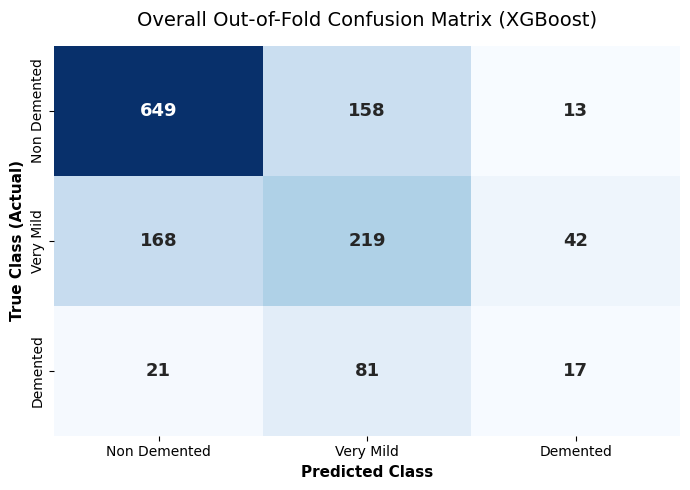

Saved 'overall_confusion_matrix.png' to Drive. Process Complete!


In [4]:

import matplotlib.pyplot as plt
import seaborn as sns

print('\n' + '=' * 60)
print('Metric Results')
print('=' * 60)

classes = ['Non Demented', 'Very Mild', 'Demented']
all_true_labels = []
all_pred_labels = []


for fold in range(1, N_SPLITS + 1):
    # Load validation data
    val_embeddings = np.load(SAVE_DIR / f'fold_{fold}_val_embeddings.npy')
    val_clinical   = np.load(SAVE_DIR / f'fold_{fold}_val_clinical.npy')
    val_labels_f   = np.load(SAVE_DIR / f'fold_{fold}_val_labels.npy')

    # Load train data to fit the scaler accurately
    train_embeddings = np.load(SAVE_DIR / f'fold_{fold}_train_embeddings.npy')
    train_clinical   = np.load(SAVE_DIR / f'fold_{fold}_train_clinical.npy')

    X_train = np.concatenate([train_embeddings, train_clinical], axis=1)
    X_val = np.concatenate([val_embeddings, val_clinical], axis=1)

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Load model and predict
    xgb_model_f = XGBClassifier()
    xgb_model_f.load_model(str(SAVE_DIR / f'xgb_fold_{fold}.json'))
    preds_f = xgb_model_f.predict(X_val_scaled)

    all_true_labels.extend(val_labels_f)
    all_pred_labels.extend(preds_f)

all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)

#  Compute Overall Confusion Matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)
report = classification_report(all_true_labels, all_pred_labels, target_names=classes)

# Save Text Results to Google Drive
with open(SAVE_DIR / 'final_classification_report.txt', 'w') as f:
    f.write("=== OVERALL OOS CROSS-VALIDATION REPORT ===\n\n")
    f.write(report)
    f.write("\n\n=== CONFUSION MATRIX ===\n")
    f.write(np.array2string(cm))

print("Saved 'final_classification_report.txt' to Drive.")

# Plot, Format, and Save Confusion Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"}
)

plt.title('Overall Out-of-Fold Confusion Matrix (XGBoost)', fontsize=14, pad=15)
plt.ylabel('True Class (Actual)', fontsize=11, weight='bold')
plt.xlabel('Predicted Class', fontsize=11, weight='bold')
plt.tight_layout()


FINAL GLOBAL OUT-OF-FOLD (OOF) CLASSIFICATION REPORT
              precision    recall  f1-score   support

Non Demented     0.7745    0.7915    0.7829       820
   Very Mild     0.4782    0.5105    0.4938       429
    Demented     0.2361    0.1429    0.1780       119

    accuracy                         0.6469      1368
   macro avg     0.4962    0.4816    0.4849      1368
weighted avg     0.6347    0.6469    0.6396      1368



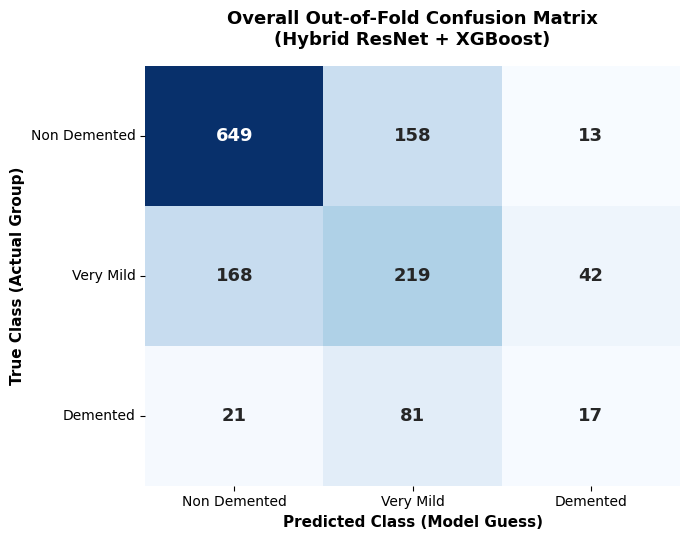


[SUCCESS] Report printed and matrix saved as 'final_oof_confusion_matrix.png'!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

#Aggregate Matrix
oof_matrix = np.array([
    [649, 158,  13],  # Row 0: Actual Non Demented
    [168, 219,  42],  # Row 1: Actual Very Mild
    [ 21,  81,  17]   # Row 2: Actual Demented
])

classes = ['Non Demented', 'Very Mild', 'Demented']


y_true = []
y_pred = []

for true_class in range(3):
    for pred_class in range(3):
        count = oof_matrix[true_class, pred_class]
        y_true.extend([true_class] * count)
        y_pred.extend([pred_class] * count)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report_string = classification_report(y_true, y_pred, target_names=classes, digits=4)

print("=" * 65)
print("FINAL GLOBAL OUT-OF-FOLD (OOF) CLASSIFICATION REPORT")
print("=" * 65)
print(report_string)
print("=" * 65)

#Heatmap
plt.figure(figsize=(7, 5.5))

sns.heatmap(
    oof_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"}
)


plt.title('Overall Out-of-Fold Confusion Matrix\n(Hybrid ResNet + XGBoost)', fontsize=13, pad=15, weight='bold')
plt.ylabel('True Class (Actual Group)', fontsize=11, weight='bold')
plt.xlabel('Predicted Class (Model Guess)', fontsize=11, weight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()


